# Model predictions and mechanisms

This notebook is for **model interpretation and not for estimation**. It keeps the main figures in the following sequence:

1. Hand-to-mouth versus heterogeneous assets.
2. Forward solved; hazard, survival, consumption, and asset paths.
3. Value functions from the backward solution.
4. Standard versus reference-dependent predictions.
5. Multi-type selection (survival)

A key distinction used throughout:
- `SolveModel()` returns policies conditional on **current assets**.
- `SolveForward()` maps those policies into paths conditional on **initial assets**.

## 1. Setup

In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta

MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    "/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/"
)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

import Model_components as model

FIGURE_DIR = os.path.join(os.getcwd(), "prediction_figures")
os.makedirs(FIGURE_DIR, exist_ok=True)


## 2. Parameters and institutions

In [ ]:
delta = 0.89 # discount factor
gamma = 0.81 # Inverse elasticity of search effort with respect to net value of employment
eta = 1 # gain/loss parameter from difference in income relative to reference income
k = 159 # Search cost parameter
k1 = 300 # search cost parameter for type 1
k2 = 150 # search cost parameter for type 2
k3 = 90 # search cost parameter for type 3
q1 = 0.33 # share of type 1 in the population
q2 = 0.33 # share of type 2 in the population
lmbda = 4.9 # loss aversion
N = 6 # reference period

abar = [0, 17955] # size of asset grid

n_a = 100 # number of asset grid points
n_c = 100 # number of consumption grid points
T1 = 6 # end of first benefit period 
T2 = 18 # end of second benefit period
T3 = 24 # end of third benefit period
T = 44 # total number of periods

# Pre-reform benefits
b1_pre = 222
b2_pre = 222
b3 = 114

# Post-reform benefits
b1_post = 342
b2_post = 171

welfare = 90 # welfare level (after benefits expire)
w = 675 # wage level
R = 0.01 # interest rate


institutions_pre = np.array([ n_a, n_c, T1, T2, T3, T, b1_pre, b2_pre, b3, welfare, w, R])
institutions_post = np.array([ n_a, n_c, T1, T2, T3, T, b1_post, b2_post, b3, welfare, w, R])

params_std = np.array([delta, gamma, 0.0, k, 0.0, N])
params_rd = np.array([delta, gamma, eta, k, lmbda, N])
params_2type = np.array([delta, gamma, 0.0, k1, 0.0, N, k2, q1])
params_3type = np.array([delta, gamma, 0.0, k1, 0.0, N, k2, k3, q1, q2])

timevec = (np.arange(T) + 1) * 15
timevec_survival = np.arange(T + 1) * 15
#timevec_mom = np.arange(35+1)*15

asset_rows = [0, 25, 50, 99]

#htm = 0 # hand to mouth indicator (1 if hand to mouth, 0 otherwise)




# 3. Hand-to-mouth versus heterogeneous assets

The HTM model has `A_t=0` and `c_t=y_t` in every period. The asset model instead starts workers at different initial asset levels and follows their optimal asset policy forward.

The first figure compares the standard one-type aggregate hazard under these two consumption environments.

In [7]:
def aggregate_hazard_from_survival(survival, weights):
    survival_total = weights @ survival
    return (
        survival_total[:-1] - survival_total[1:]
    ) / survival_total[:-1]


# Hand-to-mouth
htm = 1
weights_htm = model.make_weights(htm, abar, n_a)

C_htm_pre, S_htm_pre, surv_htm_pre, A_htm_pre, Agrid_htm, benefits_htm_pre =     model.SolveForward(params_std, institutions_pre, abar, htm)

C_htm_post, S_htm_post, surv_htm_post, A_htm_post, _, benefits_htm_post =     model.SolveForward(params_std, institutions_post, abar, htm)

# Heterogeneous assets
htm = 0
weights_assets = model.make_weights(htm, abar, n_a)

C_assets_pre, S_assets_pre, surv_assets_pre, A_assets_pre, Agrid_assets, benefits_assets_pre =     model.SolveForward(params_std, institutions_pre, abar, htm)

C_assets_post, S_assets_post, surv_assets_post, A_assets_post, _, benefits_assets_post =     model.SolveForward(params_std, institutions_post, abar, htm)

haz_htm_pre = aggregate_hazard_from_survival(surv_htm_pre, weights_htm)
haz_htm_post = aggregate_hazard_from_survival(surv_htm_post, weights_htm)

haz_assets_pre = aggregate_hazard_from_survival(surv_assets_pre, weights_assets)
haz_assets_post = aggregate_hazard_from_survival(surv_assets_post, weights_assets)

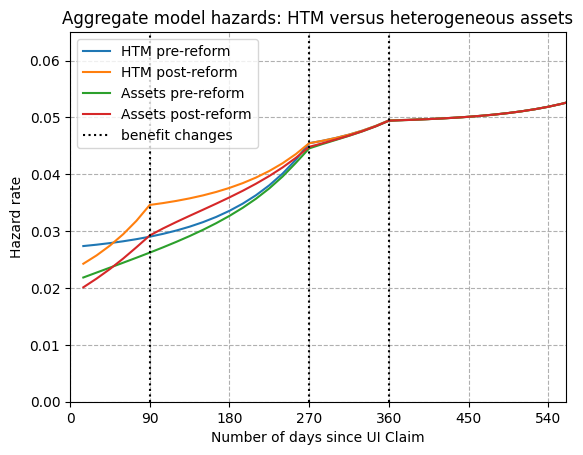

In [65]:
plt.plot(timevec, haz_htm_pre, label="HTM pre-reform")
plt.plot(timevec, haz_htm_post, label="HTM post-reform")
plt.plot(timevec, haz_assets_pre, label="Assets pre-reform")
plt.plot(timevec, haz_assets_post, label="Assets post-reform")

plt.vlines(x=[ T1*15, T2*15, T3*15], ymin=0, ymax=0.065, colors='black', linestyles=':', linewidth = 1.5, label='benefit changes')

plt.xlabel('Number of days since UI Claim')
plt.ylabel('Hazard rate')
plt.title('Aggregate model hazards: HTM versus heterogeneous assets')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.065) # set y-axis limits
plt.xticks(np.arange(0, 541, 90))
plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "htm_vs_assets_hazards.pdf"), bbox_inches="tight")

plt.show()

# 4. Heterogeneous assets: forward paths

These figures should use `SolveForward()`, because the rows then refer to **initial** asset levels. The same row in `SolveModel()` would instead hold current assets fixed and is not an individual unemployment-spell trajectory.

## 4.1 Pre-reform paths



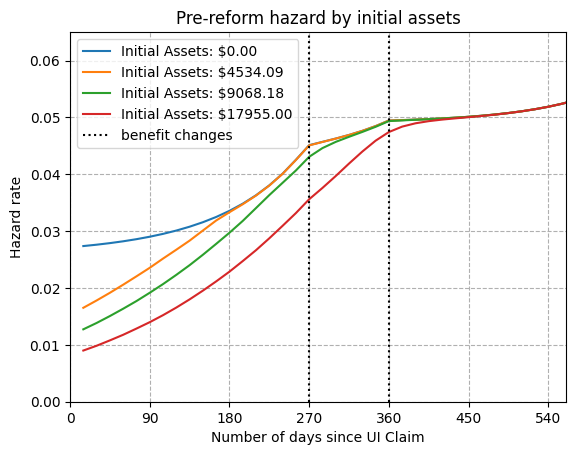

In [66]:
for i in asset_rows:
    plt.plot(timevec, S_assets_pre[i,:], label=f"Initial Assets: ${Agrid_assets[i]:.2f}")

plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=0.065, colors='black', linestyles=':', linewidth=1.5, label='benefit changes')


plt.xlabel('Number of days since UI Claim')
plt.ylabel('Hazard rate')
plt.title("Pre-reform hazard by initial assets")
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.065) # set y-axis limits
plt.xticks(np.arange(0, 541, 90))
plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "hazard_by_initial_assets_pre.pdf"), bbox_inches="tight")
plt.show()

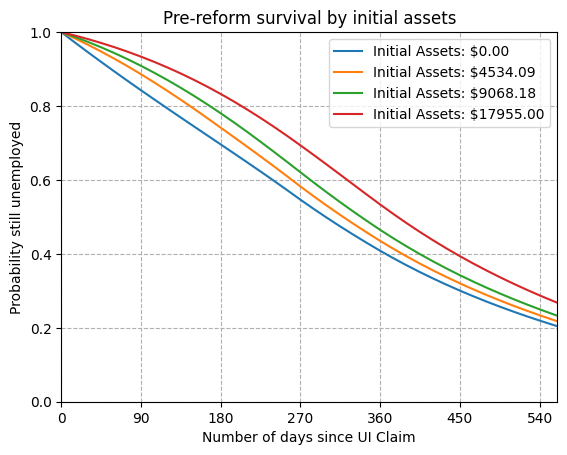

In [67]:
for i in asset_rows:
    plt.plot(timevec_survival, surv_assets_pre[i,:], label=f"Initial Assets: ${Agrid_assets[i]:.2f}")

#plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=1, colors='black', linestyles=':', linewidth=1.5, label='benefit changes')


plt.xlabel('Number of days since UI Claim')
plt.ylabel('Probability still unemployed')
plt.title("Pre-reform survival by initial assets")
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 1) # set y-axis limits
plt.xticks(np.arange(0, 541, 90))
plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "hazard_by_initial_assets_pre.pdf"), bbox_inches="tight")
plt.show()

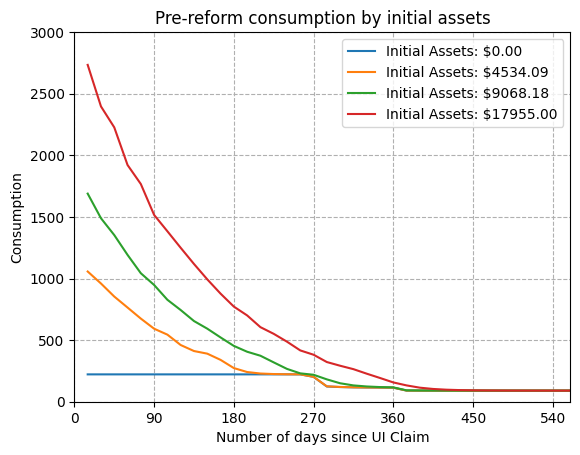

In [68]:
for i in asset_rows:
    plt.plot(timevec, C_assets_pre[i,:], label=f"Initial Assets: ${Agrid_assets[i]:.2f}")

#plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=3000, colors='black', linestyles=':', linewidth=1.5, label='benefit changes')


plt.xlabel('Number of days since UI Claim')
plt.ylabel('Consumption')
plt.title("Pre-reform consumption by initial assets")
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 3000) # set y-axis limits
plt.xticks(np.arange(0, 541, 90))
plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "hazard_by_initial_assets_pre.pdf"), bbox_inches="tight")
plt.show()

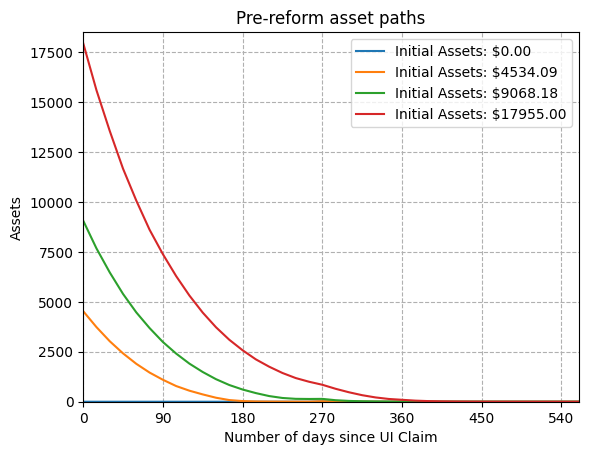

In [69]:
for i in asset_rows:
    plt.plot(timevec_survival, A_assets_pre[i,:], label=f"Initial Assets: ${Agrid_assets[i]:.2f}")

#plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=18500, colors='black', linestyles=':', linewidth=1.5, label='benefit changes')


plt.xlabel('Number of days since UI Claim')
plt.ylabel('Assets')
plt.title("Pre-reform asset paths")
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 18500) # set y-axis limits
plt.xticks(np.arange(0, 541, 90))
plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "hazard_by_initial_assets_pre.pdf"), bbox_inches="tight")
plt.show()

## 4.2 Post-reform forward paths

Post-reform is useful for showing anticipation and smoothing around the 90-day front-loaded benefit reduction.

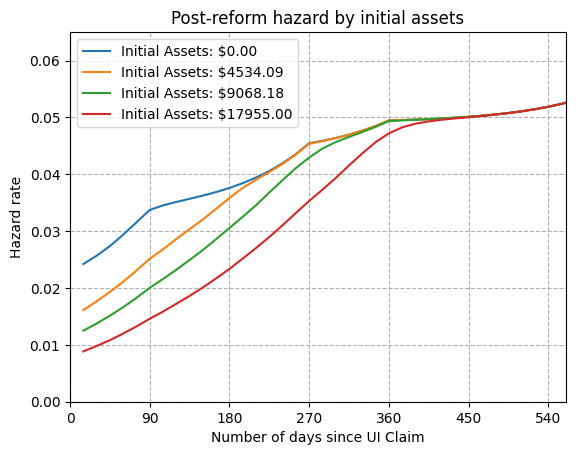

In [70]:
for i in asset_rows:
    plt.plot(timevec, S_assets_post[i,:], label=f"Initial Assets: ${Agrid_assets[i]:.2f}")

#plt.vlines(x=[T1*15, T2*15, T3*15], ymin=0, ymax=0.065, colors='black', linestyles=':', linewidth=1.5, label='benefit changes')


plt.xlabel('Number of days since UI Claim')
plt.ylabel('Hazard rate')
plt.title("Post-reform hazard by initial assets")
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.065) # set y-axis limits
plt.xticks(np.arange(0, 541, 90))
plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "hazard_by_initial_assets_post.pdf"), bbox_inches="tight")
plt.show()

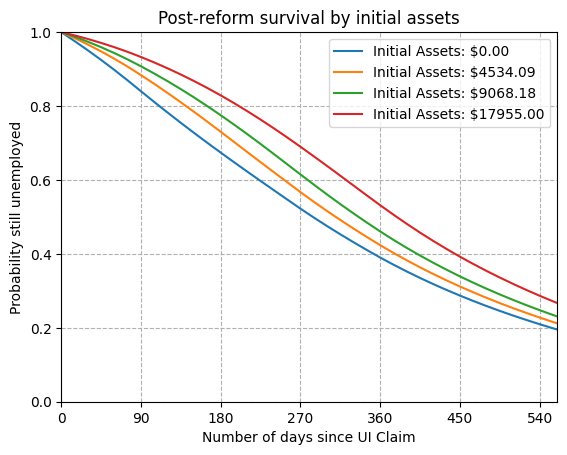

In [71]:
for i in asset_rows:
    plt.plot(timevec_survival, surv_assets_post[i,:], label=f"Initial Assets: ${Agrid_assets[i]:.2f}")

#plt.vlines(x=[ T2*15, T3*15], ymin=0, ymax=1, colors='black', linestyles=':', linewidth=1.5, label='benefit changes')


plt.xlabel('Number of days since UI Claim')
plt.ylabel('Probability still unemployed')
plt.title("Post-reform survival by initial assets")
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.xticks(np.arange(0, 541, 90))
plt.ylim(0, 1) # set y-axis limits

plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "hazard_by_initial_assets_post.pdf"), bbox_inches="tight")
plt.show()

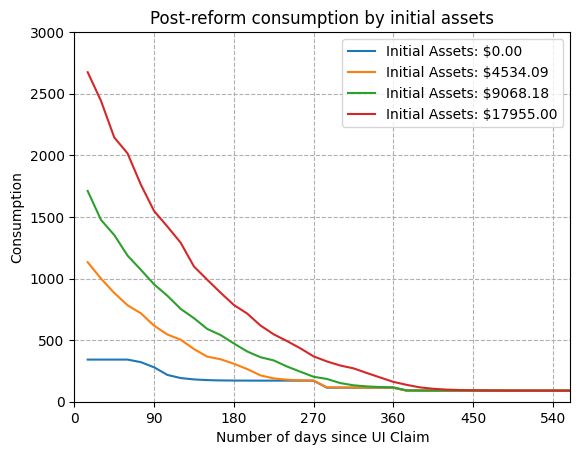

In [72]:
for i in asset_rows:
    plt.plot(timevec, C_assets_post[i,:], label=f"Initial Assets: ${Agrid_assets[i]:.2f}")

#plt.vlines(x=[T1*15, T2*15, T3*15], ymin=0, ymax=3000, colors='black', linestyles=':', linewidth=1.5, label='benefit changes')


plt.xlabel('Number of days since UI Claim')
plt.ylabel('Consumption')
plt.title("Post-reform consumption by initial assets")
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 3000) # set y-axis limits
plt.xticks(np.arange(0, 541, 90))
plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "hazard_by_initial_assets_post.pdf"), bbox_inches="tight")
plt.show()

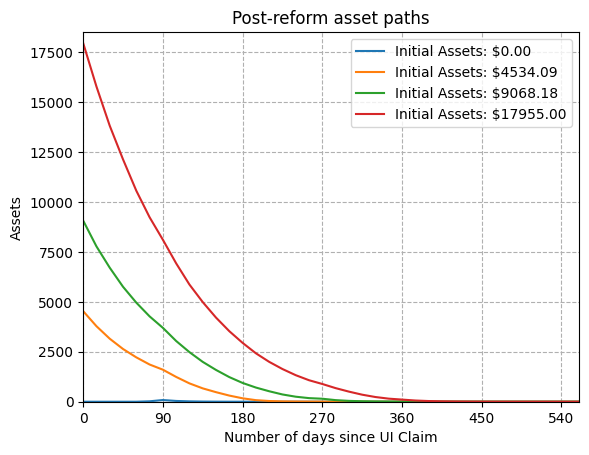

In [73]:
for i in asset_rows:
    plt.plot(timevec_survival, A_assets_post[i,:], label=f"Initial Assets: ${Agrid_assets[i]:.2f}")

#plt.vlines(x=[T1*15, T2*15, T3*15], ymin=0, ymax=18500, colors='black', linestyles=':', linewidth=1.5, label='benefit changes')


plt.xlabel('Number of days since UI Claim')
plt.ylabel('Assets')
plt.title("Post-reform asset paths")
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 18500) # set y-axis limits
plt.xticks(np.arange(0, 541, 90))
plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "hazard_by_initial_assets_post.pdf"), bbox_inches="tight")
plt.show()

# 5. Value functions

Value functions are naturally conditional on **current assets**, so here we intentionally use `SolveModel()` rather than `SolveForward()`.

Do not describe these lines as paths for workers who started at a given asset level. They answer a different question: what is the value of employment/unemployment in period `t` conditional on currently holding a particular amount of assets?

# 6. Standard versus reference dependence

This comparison isolates the reference-dependent mechanism by holding the remaining starting parameters fixed.

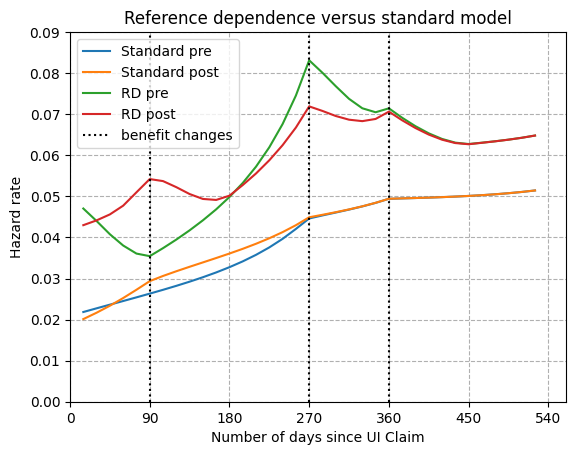

In [75]:
htm = 0
weights = model.make_weights(htm, abar, n_a)

mom_std = model.simulate_moments(
    params_std, institutions_pre, institutions_post, abar, weights, htm
)
mom_rd = model.simulate_moments(
    params_rd, institutions_pre, institutions_post, abar, weights, htm
)

def split_half(arr):
    mid = len(arr) // 2
    return np.asarray(arr[:mid]), np.asarray(arr[mid:])

std_pre, std_post = split_half(mom_std)
rd_pre, rd_post = split_half(mom_rd)

timevec_mom = np.arange(15, 526, 15)

plt.plot(timevec_mom, std_pre, label="Standard pre")
plt.plot(timevec_mom, std_post, label="Standard post")
plt.plot(timevec_mom, rd_pre, label="RD pre")
plt.plot(timevec_mom, rd_post, label="RD post")

plt.vlines(x=[ T1*15, T2*15, T3*15], ymin=0, ymax=0.09, colors='black', linestyles=':', linewidth = 1.5, label='benefit changes')

plt.xlabel('Number of days since UI Claim')
plt.ylabel('Hazard rate')
plt.title('Reference dependence versus standard model')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.ylim(0, 0.09) # set y-axis limits
plt.xticks(np.arange(0, 541, 90))
plt.legend()
plt.grid(True, linestyle='--')

plt.savefig(os.path.join(FIGURE_DIR, "standard_vs_rd.pdf"), bbox_inches="tight")
plt.show()





# 7. Heterogeneous search-cost types

The most informative mechanism figure is not only type-specific survival, but the **composition of the remaining unemployed population**. Low-`k` types search more, exit faster, and therefore become less prevalent with unemployment duration.

In [76]:
def unpack_type_structure(params_vec):
    p = np.asarray(params_vec).ravel()

    if len(p) == 8:
        d, g, e, k1_, lam, N_, k2_, q1_ = p
        return [k1_, k2_], np.array([q1_, 1-q1_]), [d, g, e, lam, N_]

    if len(p) == 10:
        d, g, e, k1_, lam, N_, k2_, k3_, q1_, q2_ = p
        return [k1_, k2_, k3_], np.array([q1_, q2_, 1-q1_-q2_]), [d, g, e, lam, N_]

    raise ValueError("Use a 2-type or 3-type parameter vector.")


def type_diagnostics(params_vec, institutions):
    kvals, shares, common = unpack_type_structure(params_vec)
    d, g, e, lam, N_ = common

    type_survival = []

    for k_j in kvals:
        params_j = np.array([d, g, e, k_j, lam, N_])
        _, _, surv_j, _, _, _ = model.SolveForward(
            params_j, institutions, abar, htm
        )
        type_survival.append(weights @ surv_j)

    type_survival = np.asarray(type_survival)

    mass = shares[:, None] * type_survival
    composition = mass / mass.sum(axis=0, keepdims=True)

    return np.asarray(kvals), shares, type_survival, composition


kvals_3, shares_3, surv_3, composition_3 =     type_diagnostics(params_3type, institutions_pre)

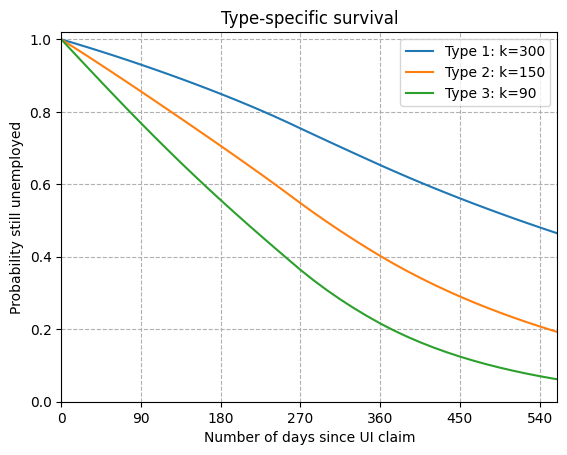

In [77]:
#fig, ax = plt.subplots(figsize=(7.2, 4.8))

for j, k_j in enumerate(kvals_3):
    plt.plot(timevec_survival, surv_3[j], label=f"Type {j+1}: k={k_j:.0f}")

plt.xlabel("Number of days since UI claim")
plt.ylabel("Probability still unemployed")
plt.title("Type-specific survival")
plt.xlim(0, 560)
plt.xticks(np.arange(0, 541, 90))
plt.ylim(0, 1.02)
plt.grid(True, linestyle="--")
plt.legend()

plt.savefig(os.path.join(FIGURE_DIR, "type_survival.pdf"), bbox_inches="tight")
plt.show()

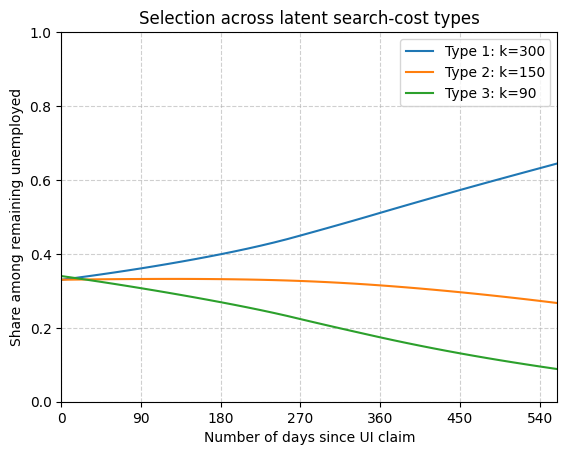

In [78]:


for j, k_j in enumerate(kvals_3):
    plt.plot(timevec_survival, composition_3[j], label=f"Type {j+1}: k={k_j:.0f}")

plt.xlabel("Number of days since UI claim")
plt.ylabel("Share among unemployed")
plt.title("Selection across latent search-cost types")
plt.xlim(0, 560)
plt.xticks(np.arange(0, 541, 90))
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.savefig(os.path.join(FIGURE_DIR, "type_composition.pdf"), bbox_inches="tight")
plt.show()

In [124]:
htm = 0
weights = model.make_weights(htm, abar, n_a)

In [125]:
S_rd, V_emp_rd, V_unemp_rd, c_emp_rd, c_unemp_rd, Vss_emp_rd, Vss_uemp_rd, css_emp_rd, css_uemp_rd, survival_rd, benefits_rd = model.SolveModel(params_rd, institutions_pre, abar, htm)
timevec_rd = np.arange((len(S_rd[0,:-1])))*15


## Predict the reference dependent model on post-reform institutions

In [131]:
S_rd_post, V_emp_rd_post, V_unemp_rd_post, c_emp_rd_post, c_unemp_rd_post, Vss_emp_rd_post, Vss_uemp_rd_post, css_emp_rd_post, css_uemp_rd_post, survival_rd_post, benefits_rd_post = model.SolveModel(params_rd, institutions_post, abar, htm)
timevec_rd_post = np.arange((len(S_rd[0,:-1])))*15

### We plot value of unemployment for the post reform against value of employment. 

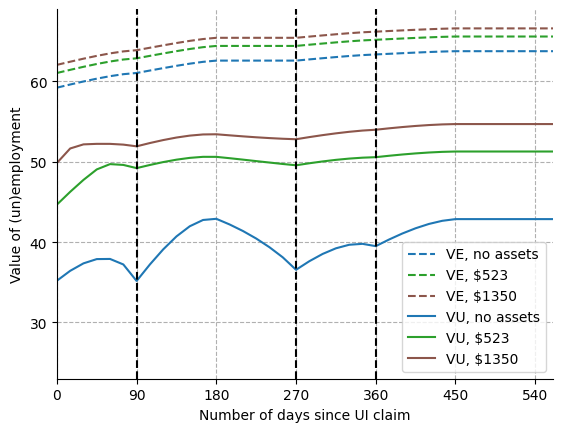

In [134]:
plt.figure(figsize=(6.4, 4.8))

plt.plot(timevec_rd_post, V_emp_rd_post[0, :-1], label="VE, no assets", linestyle='dashed', color='tab:blue')
plt.plot(timevec_rd_post, V_emp_rd_post[29, :-1], label="VE, $523", linestyle='dashed', color='tab:green')
plt.plot(timevec_rd_post, V_emp_rd_post[49, :-1], label="VE, $1350", linestyle='dashed', color='tab:brown')

plt.plot(timevec_rd_post, V_unemp_rd_post[0, :-1], label="VU, no assets", color='tab:blue')
plt.plot(timevec_rd_post, V_unemp_rd_post[29, :-1], label="VU, $523", color='tab:green')
plt.plot(timevec_rd_post, V_unemp_rd_post[49, :-1], label="VU, $1350", color='tab:brown')

plt.xlabel('Number of days since UI claim')
plt.ylabel('Value of (un)employment')
#plt.title('Post-reform Hazard Rates for Hungary')

# X-axis
plt.xlim(0, 560)
plt.xticks(np.arange(0, 541, 90))

# Y-axis
plt.ylim(bottom=23)
plt.ylim(top=69)
#plt.yticks(np.arange(0, 0.06, 0.01))

# Vertical lines for benefit changes
plt.vlines(
    x=[T1 * 15, T2 * 15, T3 * 15],
    ymin=23,
    ymax=69,
    colors='black',
    linestyles='dashed'
)

# Remove top and right frame
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc ='lower right')
plt.grid(True, linestyle='--')

plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/VE,VU post.pdf', bbox_inches='tight')


plt.show()